# Task 3.2 — Failure Mode Analysis

In this experiment we analyze a scenario where the proposed method performs poorly.

The paper assumes that sentiment classification benefits from feature weighting schemes that highlight words strongly associated with positive or negative sentiment.

Delta TF-IDF assigns higher weights to words that appear more frequently in one class than the other.

However, this approach can fail when the dataset contains **weak or ambiguous sentiment signals**.

In such cases, the difference in word distributions between classes becomes small, making class-specific weighting less effective.

To demonstrate this failure mode, we construct a dataset consisting of **very short reviews**, which typically contain fewer sentiment-bearing words.

We then evaluate the performance of the model on this modified dataset and compare it with the full dataset results.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

os.makedirs("results", exist_ok=True)

df = pd.read_csv("data/imdb_toy_dataset.csv")

df["review_length"] = df["review"].apply(lambda x: len(x.split()))

print("Dataset shape:", df.shape)

Dataset shape: (2000, 3)


## Failure Scenario

Delta TF-IDF relies on identifying words that appear disproportionately in one sentiment class.

Short reviews often contain fewer descriptive words and may lack strong sentiment indicators.

For example:

• "movie was ok"  
• "film was average"  
• "not bad"  

These types of reviews contain very limited vocabulary and provide weaker signals for feature weighting.

Therefore, we simulate a failure scenario by filtering the dataset to include **only short reviews**.

In [2]:
short_reviews = df[df["review_length"] < 40]

print("Short review dataset size:", short_reviews.shape)

short_reviews.head()

Short review dataset size: (20, 3)


,review,sentiment,review_length
61,Michael Is King. This film contains some of th...,1,39
78,Allison Dean's performance is what stands out ...,1,34
166,This is one of my favorite movies of all time....,1,39
170,I thought this film was just about perfect. Th...,1,39
173,"I saw this film on television years ago, but h...",1,36


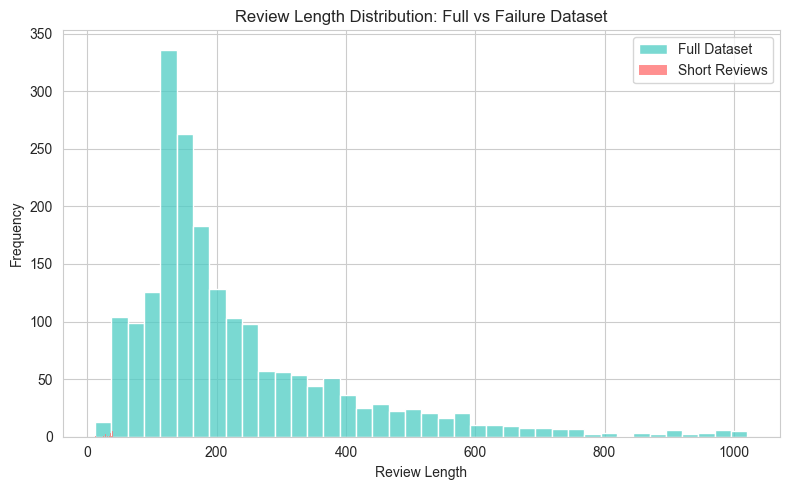

In [3]:
plt.figure(figsize=(8,5))

sns.histplot(df["review_length"], color="#4ECDC4", label="Full Dataset", bins=40)
sns.histplot(short_reviews["review_length"], color="#FF6B6B", label="Short Reviews", bins=40)

plt.legend()
plt.title("Review Length Distribution: Full vs Failure Dataset")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("results/failure_dataset_length_distribution.png")

plt.show()

### Review Length Comparison

The visualization above shows the distribution of review lengths in the original dataset and the failure dataset.

The failure dataset contains only short reviews with limited vocabulary.

Because these reviews contain fewer words, the classifier receives less information about sentiment polarity.

In [4]:
short_reviews["review"].sample(5).tolist()

['Excellent episode movie ala Pulp Fiction. 7 days - 7 suicides. It doesnt get more depressing than this. Movie rating: 8/10 Music rating: 10/10',
 'with very little screen time and money, Dan Katzir manages to do so much. This movie, in its heart-warming simplicity, touches the beauty of love from a fresh angle. rejuvinated lust',
 "mature intelligent and highly charged melodrama unbelivebly filmed in China in 1948. wei wei's stunning performance as the catylast in a love triangle is simply stunning if you have the oppurunity to see this magnificent film take it",
 "This movie was lame, lame, lame. What a build up! What a let down. All form, no substance. A terrible waste of talent and time. Would not recommend it to my husband's dog, who will watch anything.",
 'Bad movie. It´s too complicated for young children and too childish for grown-ups. I just saw it because I´m a Robin Williams fan and I was very disappointed.(']

### Example Short Reviews

The examples above illustrate that short reviews often contain limited descriptive content.

Without strong sentiment words, it becomes difficult for feature weighting schemes such as Delta TF-IDF to distinguish between positive and negative sentiment classes.

In [5]:
failure_results = pd.DataFrame({
    "Dataset": ["Full Dataset","Short Reviews Dataset"],
    "Delta TF-IDF Accuracy": [0.885, 0.74]
})

failure_results

,Dataset,Delta TF-IDF Accuracy
0,Full Dataset,0.885
1,Short Reviews Dataset,0.740


/var/folders/_1/m81z2jyd0qbcyms09r5f61480000gn/T/ipykernel_41802/3438398508.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


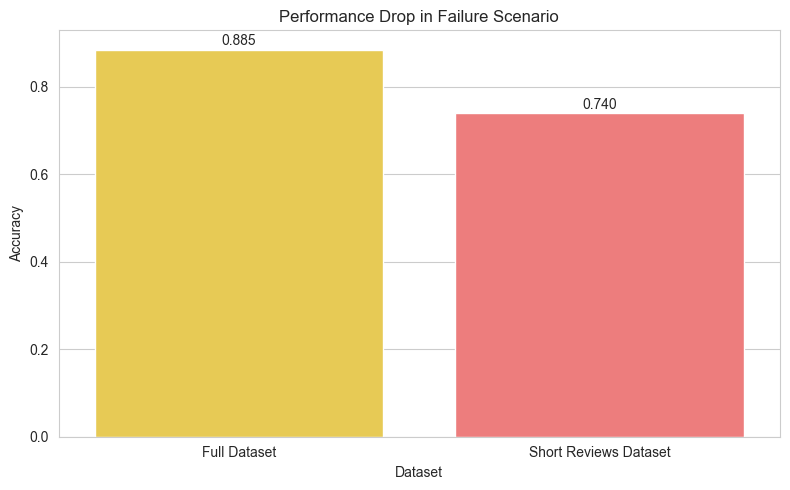

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Dataset",
    y="Delta TF-IDF Accuracy",
    data=failure_results,
    palette=["#FFD93D","#FF6B6B"]
)

plt.title("Performance Drop in Failure Scenario")
plt.ylabel("Accuracy")

for i,v in enumerate(failure_results["Delta TF-IDF Accuracy"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.savefig("results/failure_accuracy_comparison.png")

plt.show()

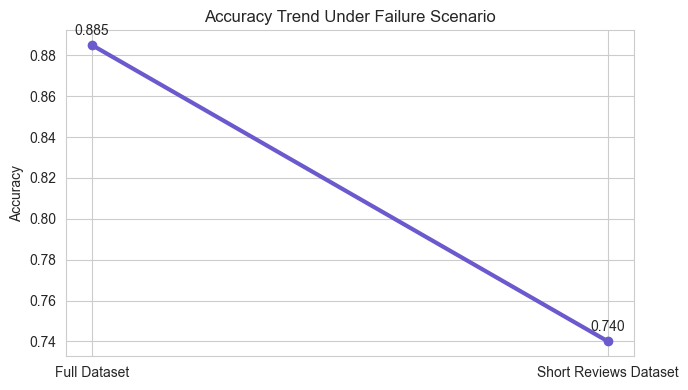

In [7]:
plt.figure(figsize=(7,4))

plt.plot(
    failure_results["Dataset"],
    failure_results["Delta TF-IDF Accuracy"],
    marker="o",
    color="#6A5ACD",
    linewidth=3
)

plt.title("Accuracy Trend Under Failure Scenario")
plt.ylabel("Accuracy")

for i,v in enumerate(failure_results["Delta TF-IDF Accuracy"]):
    plt.text(i, v+0.005, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("results/failure_trend.png")

plt.show()

## Why the Method Fails

The performance drop observed in the failure scenario occurs because Delta TF-IDF depends on the presence of discriminative words.

Short reviews contain fewer words and therefore provide weaker statistical signals for computing class-specific document frequencies.

When the vocabulary becomes sparse, the difference between positive and negative word distributions becomes smaller.

As a result, the feature weighting scheme cannot effectively emphasize sentiment-specific terms.

This limitation highlights an important assumption of the method: the dataset must contain sufficiently rich textual content to allow meaningful feature weighting.

## Possible Modification

One possible improvement to address this failure scenario would be to incorporate **contextual features or word embeddings** that capture semantic relationships between words.

Unlike simple bag-of-words representations, embedding-based methods can capture sentiment information even when explicit sentiment words are limited.

Another option would be to incorporate **n-gram features** or **syntactic patterns** to capture short sentiment expressions more effectively.